In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, pearsonr
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units, predict_loop, plot_select30_hist

In [2]:
# for now assign to x random images
def random_images(num, train = True, path = os.path.join("//imagenet-mini")):
    """
    NOTE: directory structure for subfolers as follows
    --imagenet-mini
        -->train
            -->folder1
                -->picture1-1
                -->picture2-1.....
            -->folder2...
            -->folder3...
                -->picture1-3
                -->pictuer2-3
                -->picture....
        -->validation


    Parameters
    ----------
    num: int
        number of images 
    frames: int
        number of frames
    train: bool
        using training or validation set, defaults to train
    path: string
        defaults to cwd for training folder, otherwise path to train/val. folders needed

    Returns
    -------
    folder_id
        folder # used
    image_ids
        image #'s used
    np.stack(final_array)
        stack of num DIFFERENT images in one object, shape (num, 144, 256)
    """

    if train == True: train_val = '//train' 
    else: train_val = '//val'

    folder_path = path + train_val # get path to train/val folders
    initial_folders = os.listdir(folder_path)

    folder_id = np.random.randint(0, len(initial_folders) - 1) # get path to random folder within train/val
    image_folder_path = folder_path + '//' + initial_folders[folder_id]

    image_folder = os.listdir(image_folder_path) # path to folder in train/val with images

    image_ids = np.random.randint(0,len(image_folder) - 1, size = num)
    final_array = np.empty(shape = (num, 144, 256))

    for i in range(num):
        image_name = '//' + image_folder[i]
        image_path = image_folder_path + image_name
        image = Image.open(image_path)
        image = image.convert('L')
        if image.size != (256, 144): image = image.resize((256, 144))
        image = np.array(image)
        final_array[i] = image

    return folder_id, image_ids, np.stack(final_array, axis = 0)


In [15]:
# for re-run on july 9th
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

In [3]:
folder_id, image_ids, image_stack = random_images(5, path = "C://Users//joshf//Downloads//imagenet-mini")

In [4]:
gray_frames = np.full(shape = (144, 256), fill_value = 128)

In [ ]:
# make image id = 0 gray_frames
image_stack[0] = gray_frames
image_stack.shape

(5, 144, 256)

In [6]:
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 1, image_stack, 3, [[4,7]], num_frames = 10)

In [7]:
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 1, image_stack, 15, [[4,7]], num_frames = 10)

In [8]:
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 1, image_stack, 30, [[4,7]], num_frames = 10)

In [9]:
constant3, constant3_mean, constant3_var = predict_loop('constant', 1, image_stack, 3, [[4,7]], num_frames = 10)

In [10]:
constant15, constant15_mean, constant15_var = predict_loop('constant', 1, image_stack, 15, [[4,7]], num_frames = 10)

In [11]:
constant30, constant30_mean, constant30_var = predict_loop('constant', 1, image_stack, 30, [[4,7]], num_frames = 10)

In [27]:
constant30.shape

(5, 1, 7493)

In [ ]:
def turning_curve(array, title, ten_neurons):
    # input must be 2d array, ie mean or var array from prediction
    fix, ax = plt.subplots(1,1, figsize = (6,10))
    
    image_ids = np.array([i for i in range(5)], dtype = int)
    
    # error bar
    variance = np.var(array, axis = 1)
    std_dev = np.sqrt(variance)
    
    for neuron in ten_neurons:
        neuron_predictions = array[:, neuron]
        plt.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron], marker = 'o', linestyle = '-', capsize=5)
    
    plt.title(f"Turning Curve for Imagenet Images\n{title}")
    plt.xlabel("Image ID")
    plt.ylabel('Mean Neuron Prediction')

    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.grid()
    plt.tight_layout()
    plt.show()

In [29]:
final_prediction_arrays = [dynamic3_mean, dynamic15_mean, dynamic30_mean, constant3_mean, constant15_mean, constant30_mean]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def turning_curve(arrays: np.array, title: str, ten_neurons):
    """
    Parameters
    ----------
    arrays : list of np.ndarray
        List of six 2D arrays, each with shape (num_images, num_neurons), ordered as
        [Dynamic σ=3, Dynamic σ=15, Dynamic σ=30, Constant σ=3, Constant σ=15, Constant σ=30].
    ten_neurons : list of int
        List of neuron indices to plot in each subplot.

    Returns
    -------
    None
        Displays a 3x2 grid of error bar plots.
    """
    fig, ax = plt.subplots(3, 2, figsize=(12, 15), sharex=True, sharey=True)

    sigma_values = [3, 15, 30]
    subplot_titles = [f"Sigma = {sigma}" for sigma in sigma_values]

    image_ids = np.arange(arrays[0].shape[0])

    subplot_indices = [0, 2, 4, 1, 3, 5] 

    for i, array_idx in enumerate(subplot_indices):
        array = arrays[i]
        sigma_title = subplot_titles[i // 2] 
        row = i // 2
        col = i % 2
        ax_flat = ax[row, col]

        std_dev = np.std(array, axis=0) 

        for neuron in ten_neurons:
            neuron_predictions = array[:, neuron]
            ax_flat.errorbar(image_ids, neuron_predictions, yerr=std_dev[neuron], 
                            marker='o', linestyle='-', capsize=5, label=f'Neuron {neuron}')

        ax_flat.set_title(sigma_title)
        ax_flat.set_xlabel("Image ID")
        ax_flat.set_ylabel(title)
        ax_flat.xaxis.set_major_locator(MultipleLocator(1))
        ax_flat.grid(True)
        

    fig.text(0.25, 1, "Dynamic Noise", ha='center', va='center', fontsize=14, fontweight='bold')
    fig.text(0.75, 1, "Constant Noise", ha='center', va='center', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

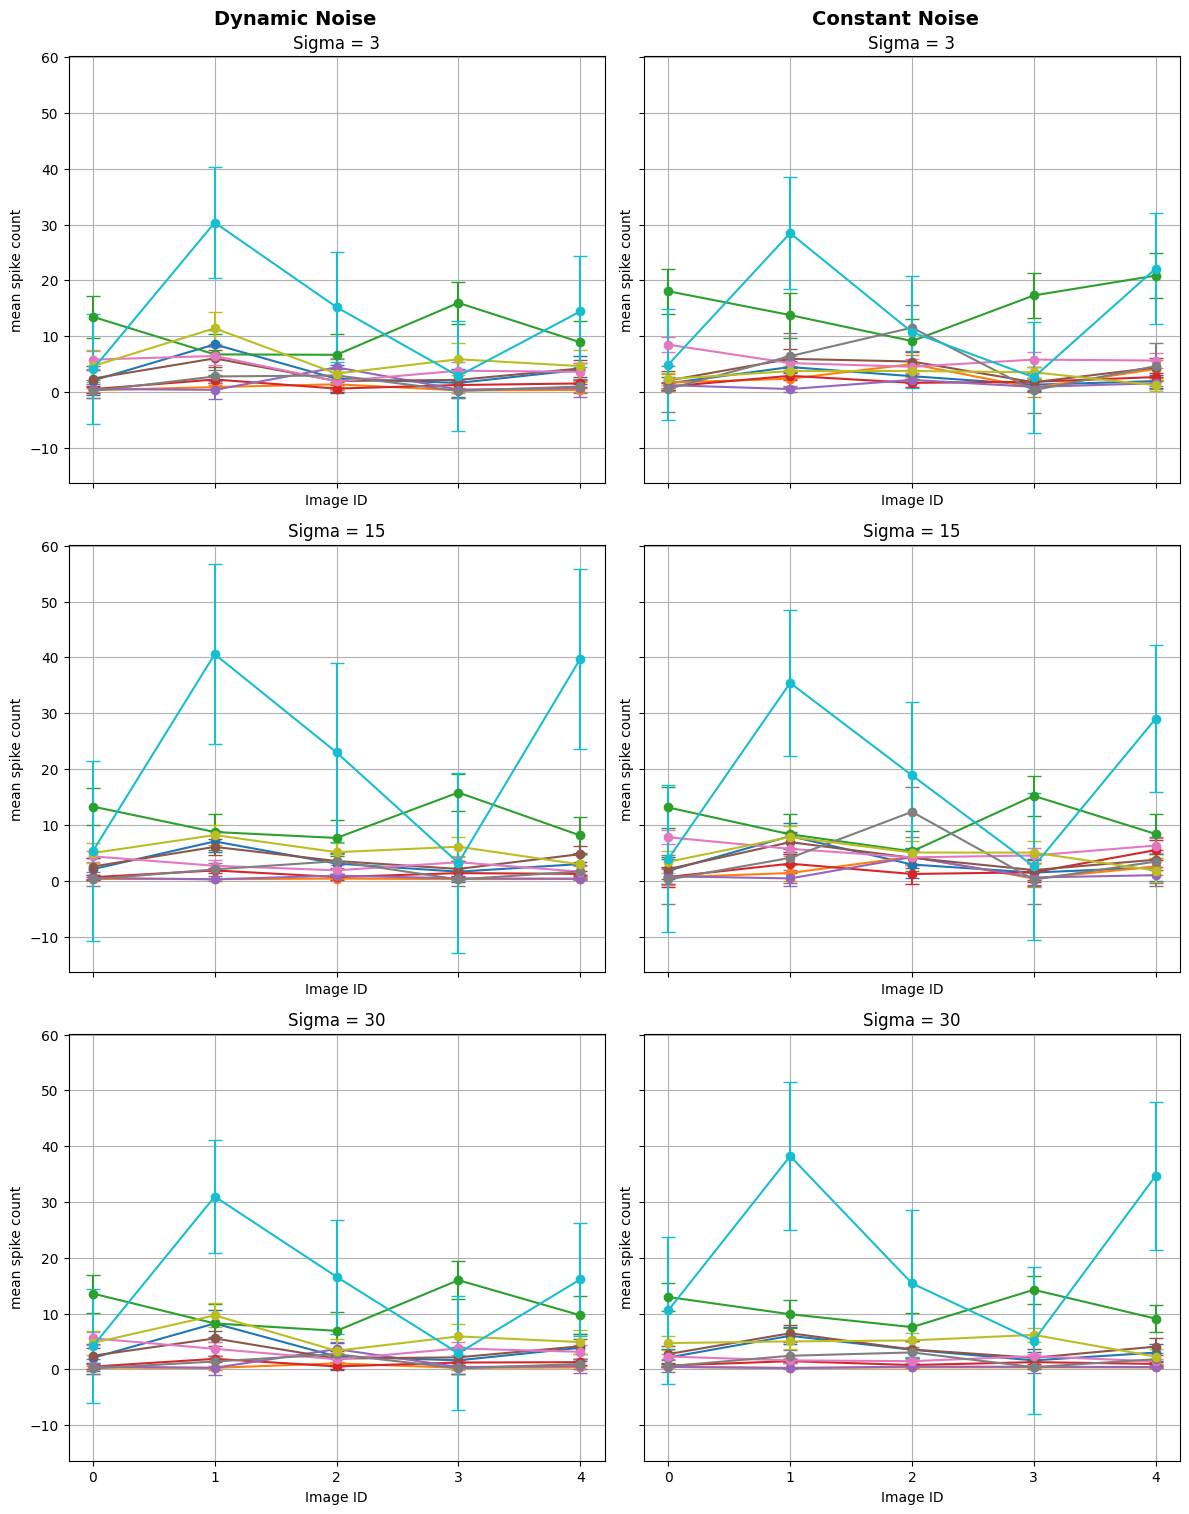

In [59]:
turning_curve(final_prediction_arrays,'mean spike count', neurons[:10])